# 05. External Validation on the YooChoose Dataset

This notebook externally validates the cart-to-purchase prediction framework on the YooChoose e-commerce dataset. Because YooChoose contains session-level rather than persistent user-level identifiers, equivalent session-based behavioral features are constructed and evaluated separately.

In [1]:
# Purpose: Locate the YooChoose files, create output folders, and inspect the dataset documentation.

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

current_path = Path.cwd().resolve()

project_root = next(
    (
        candidate
        for candidate in [current_path, *current_path.parents]
        if (candidate / "data").exists()
    ),
    current_path
)

yoochoose_dir = project_root / "data" / "raw" / "yoochoose"
processed_data_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
tables_dir = project_root / "outputs" / "tables"

clicks_path = yoochoose_dir / "yoochoose-clicks.dat"
buys_path = yoochoose_dir / "yoochoose-buys.dat"
readme_path = yoochoose_dir / "dataset-README.txt"

for directory in [processed_data_dir, figures_dir, tables_dir]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Clicks file exists: {clicks_path.exists()}")
print(f"Buys file exists: {buys_path.exists()}")
print(f"README file exists: {readme_path.exists()}")

if readme_path.exists():
    print("\nYooChoose dataset README:\n")
    print(readme_path.read_text(encoding='utf-8', errors='replace'))

Project root: F:\ecommerce-recommender-xai
Clicks file exists: True
Buys file exists: True
README file exists: True

YooChoose dataset README:

﻿SUMMARY

This dataset was constructed by YOOCHOOSE GmbH to support participants in the RecSys Challenge 2015.
See  http://recsys.yoochoose.net for details about the challenge.

The YOOCHOOSE dataset contain a collection of sessions from a retailer, where each session
is encapsulating the click events that the user performed in the session.
For some of the sessions, there are also buy events; means that the session ended
with the user bought something from the web shop. The data was collected during several
months in the year of 2014, reflecting the clicks and purchases performed by the users
of an on-line retailer in Europe.  To protect end users privacy, as well as the retailer,
all numbers have been modified. Do not try to reveal the identity of the retailer.

LICENSE
This dataset is licensed under the Creative Commons Attribution-NonCommerc

In [2]:
# Purpose: Inspect the YooChoose file sizes, columns, and a small sample without loading the full datasets into memory.

click_column_names = ["session_id", "timestamp", "item_id", "category"]
buy_column_names = ["session_id", "timestamp", "item_id", "price", "quantity"]

file_overview = pd.DataFrame({
    "file": ["yoochoose-clicks.dat", "yoochoose-buys.dat"],
    "exists": [clicks_path.exists(), buys_path.exists()],
    "size_gb": [
        round(clicks_path.stat().st_size / (1024 ** 3), 2),
        round(buys_path.stat().st_size / (1024 ** 3), 2)
    ]
})

print("YooChoose file overview:")
display(file_overview)

clicks_preview = pd.read_csv(
    clicks_path,
    header=None,
    names=click_column_names,
    nrows=5
)

buys_preview = pd.read_csv(
    buys_path,
    header=None,
    names=buy_column_names,
    nrows=5
)

print("Clicks file preview:")
display(clicks_preview)

print("Buys file preview:")
display(buys_preview)

YooChoose file overview:


,file,exists,size_gb
0,yoochoose-clicks.dat,True,1.38
1,yoochoose-buys.dat,True,0.05


Clicks file preview:


,session_id,timestamp,item_id,category
0,1,2014-04-07T10:51:09.277Z,214536502,0
1,1,2014-04-07T10:54:09.868Z,214536500,0
2,1,2014-04-07T10:54:46.998Z,214536506,0
3,1,2014-04-07T10:57:00.306Z,214577561,0
4,2,2014-04-07T13:56:37.614Z,214662742,0


Buys file preview:


,session_id,timestamp,item_id,price,quantity
0,420374,2014-04-06T18:44:58.314Z,214537888,12462,1
1,420374,2014-04-06T18:44:58.325Z,214537850,10471,1
2,281626,2014-04-06T09:40:13.032Z,214535653,1883,1
3,420368,2014-04-04T06:13:28.848Z,214530572,6073,1
4,420368,2014-04-04T06:13:28.858Z,214835025,2617,1


In [3]:
# Purpose: Load and summarize all YooChoose purchase records to define the external-validation outcome.

yoochoose_buys_df = pd.read_csv(
    buys_path,
    header=None,
    names=buy_column_names,
    parse_dates=["timestamp"]
)

buy_summary = pd.DataFrame({
    "metric": [
        "Total buy records",
        "Unique purchasing sessions",
        "Unique purchased items",
        "Unique session-item purchase pairs",
        "First recorded purchase",
        "Last recorded purchase"
    ],
    "value": [
        len(yoochoose_buys_df),
        yoochoose_buys_df["session_id"].nunique(),
        yoochoose_buys_df["item_id"].nunique(),
        yoochoose_buys_df[["session_id", "item_id"]].drop_duplicates().shape[0],
        yoochoose_buys_df["timestamp"].min(),
        yoochoose_buys_df["timestamp"].max()
    ]
})

display(buy_summary)

print("\nPurchase-record preview:")
display(yoochoose_buys_df.head())

,metric,value
0,Total buy records,1150753
1,Unique purchasing sessions,509696
2,Unique purchased items,19949
3,Unique session-item purchase pairs,1049817
4,First recorded purchase,2014-04-01 03:05:31.743000+00:00
5,Last recorded purchase,2014-09-30 02:35:12.859000+00:00



Purchase-record preview:


,session_id,timestamp,item_id,price,quantity
0,420374,2014-04-06 18:44:58.314000+00:00,214537888,12462,1
1,420374,2014-04-06 18:44:58.325000+00:00,214537850,10471,1
2,281626,2014-04-06 09:40:13.032000+00:00,214535653,1883,1
3,420368,2014-04-04 06:13:28.848000+00:00,214530572,6073,1
4,420368,2014-04-04 06:13:28.858000+00:00,214835025,2617,1


In [4]:
# Purpose: Extract and save a reproducible one-sixty-fourth session sample from the large YooChoose clicks file.

SESSION_SAMPLE_DIVISOR = 64
click_chunk_size = 500_000

sampled_clicks_path = (
    processed_data_dir / "yoochoose_clicks_session_sample_1_64.csv"
)

selected_click_chunks = []
total_click_records_scanned = 0
total_sampled_click_records = 0

click_dtypes = {
    "session_id": "int32",
    "timestamp": "string",
    "item_id": "int32",
    "category": "string"
}

for chunk_number, click_chunk in enumerate(
    pd.read_csv(
        clicks_path,
        header=None,
        names=click_column_names,
        dtype=click_dtypes,
        chunksize=click_chunk_size
    ),
    start=1
):
    total_click_records_scanned += len(click_chunk)

    sampled_chunk = click_chunk.loc[
        click_chunk["session_id"] % SESSION_SAMPLE_DIVISOR == 0
    ].copy()

    total_sampled_click_records += len(sampled_chunk)
    selected_click_chunks.append(sampled_chunk)

    if chunk_number % 10 == 0:
        print(
            f"Processed {total_click_records_scanned:,} click records; "
            f"selected {total_sampled_click_records:,} records so far."
        )

yoochoose_clicks_sample = pd.concat(
    selected_click_chunks,
    ignore_index=True
)

yoochoose_clicks_sample["timestamp"] = pd.to_datetime(
    yoochoose_clicks_sample["timestamp"],
    utc=True
)

yoochoose_clicks_sample.to_csv(sampled_clicks_path, index=False)

print(f"\nTotal click records scanned: {total_click_records_scanned:,}")
print(f"Sampled click records: {len(yoochoose_clicks_sample):,}")
print(
    "Approximate click-record sampling fraction: "
    f"{len(yoochoose_clicks_sample) / total_click_records_scanned:.2%}"
)
print(
    "Unique sampled sessions: "
    f"{yoochoose_clicks_sample['session_id'].nunique():,}"
)
print(f"Saved sampled clicks to: {sampled_clicks_path}")

Processed 5,000,000 click records; selected 77,987 records so far.
Processed 10,000,000 click records; selected 156,027 records so far.
Processed 15,000,000 click records; selected 232,758 records so far.
Processed 20,000,000 click records; selected 309,322 records so far.
Processed 25,000,000 click records; selected 386,955 records so far.
Processed 30,000,000 click records; selected 465,236 records so far.

Total click records scanned: 33,003,944
Sampled click records: 512,066
Approximate click-record sampling fraction: 1.55%
Unique sampled sessions: 144,527
Saved sampled clicks to: F:\ecommerce-recommender-xai\data\processed\yoochoose_clicks_session_sample_1_64.csv


In [5]:
# Purpose: Match purchase records to the sampled click sessions and summarize the external-validation sample.

sampled_session_ids = yoochoose_clicks_sample["session_id"].unique()

yoochoose_buys_sample = yoochoose_buys_df.loc[
    yoochoose_buys_df["session_id"].isin(sampled_session_ids)
].copy()

sampled_buys_path = (
    processed_data_dir / "yoochoose_buys_session_sample_1_64.csv"
)
yoochoose_buys_sample.to_csv(sampled_buys_path, index=False)

sample_purchase_summary = pd.DataFrame({
    "metric": [
        "Sampled click records",
        "Sampled sessions",
        "Sampled purchase records",
        "Sampled purchasing sessions",
        "Sampled session-item purchase pairs",
        "Session-level purchase rate",
        "First sampled click",
        "Last sampled click"
    ],
    "value": [
        len(yoochoose_clicks_sample),
        yoochoose_clicks_sample["session_id"].nunique(),
        len(yoochoose_buys_sample),
        yoochoose_buys_sample["session_id"].nunique(),
        yoochoose_buys_sample[["session_id", "item_id"]].drop_duplicates().shape[0],
        yoochoose_buys_sample["session_id"].nunique()
        / yoochoose_clicks_sample["session_id"].nunique(),
        yoochoose_clicks_sample["timestamp"].min(),
        yoochoose_clicks_sample["timestamp"].max()
    ]
})

display(sample_purchase_summary)

print(f"Saved sampled purchases to: {sampled_buys_path}")

,metric,value
0,Sampled click records,512066
1,Sampled sessions,144527
2,Sampled purchase records,17782
3,Sampled purchasing sessions,7945
4,Sampled session-item purchase pairs,16235
5,Session-level purchase rate,0.054972
6,First sampled click,2014-04-01 03:09:05.139000+00:00
7,Last sampled click,2014-09-30 02:59:47.397000+00:00


Saved sampled purchases to: F:\ecommerce-recommender-xai\data\processed\yoochoose_buys_session_sample_1_64.csv


In [6]:
# Purpose: Create labeled session-item click candidates for predicting whether a clicked item is later bought in the same session.

sampled_clicks_sorted = yoochoose_clicks_sample.sort_values(
    ["session_id", "timestamp"]
).copy()

first_click_candidates = (
    sampled_clicks_sorted
    .groupby(["session_id", "item_id"], as_index=False)
    .agg(
        first_click_time=("timestamp", "min"),
        last_click_time=("timestamp", "max"),
        total_clicks_on_item=("timestamp", "size")
    )
)

first_purchase_per_pair = (
    yoochoose_buys_sample
    .groupby(["session_id", "item_id"], as_index=False)
    .agg(
        first_purchase_time=("timestamp", "min")
    )
)

yoochoose_candidates = first_click_candidates.merge(
    first_purchase_per_pair,
    on=["session_id", "item_id"],
    how="left"
)

yoochoose_candidates["purchased_later_in_session"] = (
    yoochoose_candidates["first_purchase_time"].notna()
    & (
        yoochoose_candidates["first_purchase_time"]
        >= yoochoose_candidates["first_click_time"]
    )
).astype(int)

candidate_label_summary = pd.DataFrame({
    "metric": [
        "Unique session-item click candidates",
        "Positive click-to-purchase candidates",
        "Click-to-purchase rate",
        "Purchased session-item pairs not linked to a click candidate"
    ],
    "value": [
        len(yoochoose_candidates),
        int(yoochoose_candidates["purchased_later_in_session"].sum()),
        yoochoose_candidates["purchased_later_in_session"].mean(),
        int(
            len(first_purchase_per_pair)
            - yoochoose_candidates["purchased_later_in_session"].sum()
        )
    ]
})

display(candidate_label_summary)

display(yoochoose_candidates.head())

yoochoose_candidates_path = (
    processed_data_dir / "yoochoose_session_item_candidates_labeled.csv"
)
yoochoose_candidates.to_csv(yoochoose_candidates_path, index=False)

print(f"Saved labeled candidates to: {yoochoose_candidates_path}")

,metric,value
0,Unique session-item click candidates,413400.000000
1,Positive click-to-purchase candidates,16221.000000
2,Click-to-purchase rate,0.039238
3,Purchased session-item pairs not linked to a c...,14.000000


,session_id,item_id,first_click_time,last_click_time,total_clicks_on_item,first_purchase_time,purchased_later_in_session
0,64,214537779,2014-04-02 19:52:44.743000+00:00,2014-04-02 19:52:44.743000+00:00,1,NaT,0
1,64,214662975,2014-04-02 19:50:43.683000+00:00,2014-04-02 19:50:43.683000+00:00,1,NaT,0
2,64,214840762,2014-04-02 19:54:03.319000+00:00,2014-04-02 19:54:03.319000+00:00,1,NaT,0
3,128,214826615,2014-04-06 09:41:38.816000+00:00,2014-04-06 09:41:38.816000+00:00,1,NaT,0
4,128,214826623,2014-04-06 09:33:27.228000+00:00,2014-04-06 09:33:27.228000+00:00,1,NaT,0


Saved labeled candidates to: F:\ecommerce-recommender-xai\data\processed\yoochoose_session_item_candidates_labeled.csv


In [7]:
# Purpose: Build leakage-safe session and item features available before each candidate's first click.

session_ordered_clicks = yoochoose_clicks_sample.sort_values(
    ["session_id", "timestamp", "item_id"]
).copy()

session_ordered_clicks["session_prior_click_count"] = (
    session_ordered_clicks.groupby("session_id").cumcount()
)

session_ordered_clicks["session_start_time"] = (
    session_ordered_clicks.groupby("session_id")["timestamp"].transform("min")
)

first_click_event_features = (
    session_ordered_clicks
    .drop_duplicates(["session_id", "item_id"], keep="first")
    [
        [
            "session_id",
            "item_id",
            "timestamp",
            "category",
            "session_prior_click_count",
            "session_start_time"
        ]
    ]
    .rename(columns={"timestamp": "first_click_time"})
)

global_time_ordered_clicks = yoochoose_clicks_sample.sort_values(
    ["timestamp", "session_id", "item_id"]
).copy()

global_time_ordered_clicks["item_global_clicks_before"] = (
    global_time_ordered_clicks.groupby("item_id").cumcount()
)

first_global_item_events = (
    global_time_ordered_clicks
    .drop_duplicates(["session_id", "item_id"], keep="first")
    [
        [
            "session_id",
            "item_id",
            "item_global_clicks_before"
        ]
    ]
)

candidate_unique_item_history = (
    yoochoose_candidates[
        ["session_id", "item_id", "first_click_time"]
    ]
    .sort_values(["session_id", "first_click_time", "item_id"])
    .copy()
)

candidate_unique_item_history["session_prior_unique_item_count"] = (
    candidate_unique_item_history.groupby("session_id").cumcount()
)

yoochoose_feature_data = (
    yoochoose_candidates
    .merge(
        first_click_event_features,
        on=["session_id", "item_id", "first_click_time"],
        how="left"
    )
    .merge(
        first_global_item_events,
        on=["session_id", "item_id"],
        how="left"
    )
    .merge(
        candidate_unique_item_history[
            [
                "session_id",
                "item_id",
                "session_prior_unique_item_count"
            ]
        ],
        on=["session_id", "item_id"],
        how="left"
    )
)

yoochoose_feature_data["session_elapsed_seconds"] = (
    yoochoose_feature_data["first_click_time"]
    - yoochoose_feature_data["session_start_time"]
).dt.total_seconds()

yoochoose_feature_data["session_prior_click_rate"] = np.where(
    yoochoose_feature_data["session_elapsed_seconds"] > 0,
    yoochoose_feature_data["session_prior_click_count"]
    / yoochoose_feature_data["session_elapsed_seconds"],
    0
)

for count_column in [
    "session_prior_click_count",
    "session_prior_unique_item_count",
    "item_global_clicks_before"
]:
    yoochoose_feature_data[f"log_{count_column}"] = np.log1p(
        yoochoose_feature_data[count_column]
    )

yoochoose_feature_data["log_session_elapsed_seconds"] = np.log1p(
    yoochoose_feature_data["session_elapsed_seconds"]
)

yoochoose_feature_data["click_hour"] = (
    yoochoose_feature_data["first_click_time"].dt.hour
)

yoochoose_feature_data["click_dayofweek"] = (
    yoochoose_feature_data["first_click_time"].dt.dayofweek
)

feature_check_columns = [
    "session_prior_click_count",
    "session_prior_unique_item_count",
    "item_global_clicks_before",
    "session_elapsed_seconds",
    "session_prior_click_rate",
    "category"
]

print("Missing values in newly created pre-click features:")
display(
    yoochoose_feature_data[feature_check_columns]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

display(
    yoochoose_feature_data[
        [
            "session_id",
            "item_id",
            "first_click_time",
            "session_prior_click_count",
            "session_prior_unique_item_count",
            "item_global_clicks_before",
            "session_elapsed_seconds",
            "purchased_later_in_session"
        ]
    ].head()
)

Missing values in newly created pre-click features:


,missing_count
session_prior_click_count,0
session_prior_unique_item_count,0
item_global_clicks_before,0
session_elapsed_seconds,0
session_prior_click_rate,0
category,0


,session_id,item_id,first_click_time,session_prior_click_count,session_prior_unique_item_count,item_global_clicks_before,session_elapsed_seconds,purchased_later_in_session
0,64,214537779,2014-04-02 19:52:44.743000+00:00,1,1,0,121.060,0
1,64,214662975,2014-04-02 19:50:43.683000+00:00,0,0,0,0.000,0
2,64,214840762,2014-04-02 19:54:03.319000+00:00,2,2,37,199.636,0
3,128,214826615,2014-04-06 09:41:38.816000+00:00,1,1,9,491.588,0
4,128,214826623,2014-04-06 09:33:27.228000+00:00,0,0,29,0.000,0


In [8]:
# Purpose: Define leakage-safe external-validation features, save the dataset, and create a chronological train-test split.

external_target_column = "purchased_later_in_session"

external_feature_columns = [
    "category",
    "log_session_prior_click_count",
    "log_session_prior_unique_item_count",
    "log_item_global_clicks_before",
    "log_session_elapsed_seconds",
    "session_prior_click_rate",
    "click_hour",
    "click_dayofweek"
]

yoochoose_feature_data["category"] = (
    yoochoose_feature_data["category"]
    .fillna("missing")
    .astype(str)
)

external_modeling_columns = [
    "session_id",
    "item_id",
    "first_click_time",
    external_target_column,
    *external_feature_columns
]

external_modeling_df = yoochoose_feature_data[
    external_modeling_columns
].copy()

external_modeling_path = (
    processed_data_dir / "yoochoose_click_to_purchase_modeling_dataset.csv"
)
external_modeling_df.to_csv(external_modeling_path, index=False)

external_time_cutoff = external_modeling_df["first_click_time"].quantile(0.80)

external_train_df = (
    external_modeling_df
    .loc[external_modeling_df["first_click_time"] <= external_time_cutoff]
    .copy()
)

external_test_df = (
    external_modeling_df
    .loc[external_modeling_df["first_click_time"] > external_time_cutoff]
    .copy()
)

X_external_train = external_train_df[external_feature_columns]
y_external_train = external_train_df[external_target_column]

X_external_test = external_test_df[external_feature_columns]
y_external_test = external_test_df[external_target_column]

print(f"External time split point: {external_time_cutoff}")
print(f"\nExternal training set shape: {X_external_train.shape}")
print(f"External test set shape: {X_external_test.shape}")
print(f"\nTraining purchase rate: {y_external_train.mean():.2%}")
print(f"Test purchase rate: {y_external_test.mean():.2%}")
print(f"\nSaved external modeling dataset to: {external_modeling_path}")

External time split point: 2014-08-25 20:04:51.262200064+00:00

External training set shape: (330720, 8)
External test set shape: (82680, 8)

Training purchase rate: 3.82%
Test purchase rate: 4.35%

Saved external modeling dataset to: F:\ecommerce-recommender-xai\data\processed\yoochoose_click_to_purchase_modeling_dataset.csv


In [9]:
# Purpose: Establish an external-validation majority-class baseline and define evaluation metrics for imbalanced click-to-purchase prediction.

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

def evaluate_external_classifier(model_name, y_true, y_pred, y_probability):
    true_negative, false_positive, false_negative, true_positive = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": true_negative / (true_negative + false_positive),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "pr_auc": average_precision_score(y_true, y_probability),
        "true_negative": true_negative,
        "false_positive": false_positive,
        "false_negative": false_negative,
        "true_positive": true_positive
    }

external_baseline_model = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

external_baseline_model.fit(X_external_train, y_external_train)

baseline_predictions = external_baseline_model.predict(X_external_test)
baseline_probabilities = external_baseline_model.predict_proba(X_external_test)[:, 1]

external_results = [
    evaluate_external_classifier(
        "Majority Class Baseline",
        y_external_test,
        baseline_predictions,
        baseline_probabilities
    )
]

print(external_results[0])

{'model': 'Majority Class Baseline', 'accuracy': 0.9565432994678278, 'precision': 0.0, 'recall_sensitivity': 0.0, 'specificity': np.float64(1.0), 'f1_score': 0.0, 'roc_auc': 0.5, 'pr_auc': 0.04345670053217223, 'true_negative': np.int64(79087), 'false_positive': np.int64(0), 'false_negative': np.int64(3593), 'true_positive': np.int64(0)}


In [10]:
# Purpose: Tune a CatBoost click-to-purchase model using a chronological validation split within the YooChoose training period.

from catboost import CatBoostClassifier

external_development_cutoff = external_train_df["first_click_time"].quantile(0.80)

external_development_df = (
    external_train_df
    .loc[external_train_df["first_click_time"] <= external_development_cutoff]
    .copy()
)

external_validation_df = (
    external_train_df
    .loc[external_train_df["first_click_time"] > external_development_cutoff]
    .copy()
)

X_external_development = external_development_df[external_feature_columns]
y_external_development = external_development_df[external_target_column]

X_external_validation = external_validation_df[external_feature_columns]
y_external_validation = external_validation_df[external_target_column]

external_categorical_features = ["category"]

print(f"Development set shape: {X_external_development.shape}")
print(f"Validation set shape: {X_external_validation.shape}")
print(f"\nDevelopment purchase rate: {y_external_development.mean():.2%}")
print(f"Validation purchase rate: {y_external_validation.mean():.2%}")

external_catboost_tuning_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=100,
    allow_writing_files=False
)

external_catboost_tuning_model.fit(
    X_external_development,
    y_external_development,
    cat_features=external_categorical_features,
    eval_set=(X_external_validation, y_external_validation),
    early_stopping_rounds=100,
    verbose=100
)

best_external_iteration = (
    external_catboost_tuning_model.get_best_iteration() + 1
)

print(
    "\nBest CatBoost iteration based on external validation AUC: "
    f"{best_external_iteration}"
)

Development set shape: (264576, 8)
Validation set shape: (66144, 8)

Development purchase rate: 3.67%
Validation purchase rate: 4.40%
0:	test: 0.5262783	best: 0.5262783 (0)	total: 330ms	remaining: 5m 29s
100:	test: 0.6363986	best: 0.6364306 (98)	total: 15.8s	remaining: 2m 20s
200:	test: 0.6498071	best: 0.6498283 (199)	total: 30.8s	remaining: 2m 2s
300:	test: 0.6505808	best: 0.6514963 (222)	total: 45s	remaining: 1m 44s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6514963364
bestIteration = 222

Shrink model to first 223 iterations.

Best CatBoost iteration based on external validation AUC: 223


In [11]:
# Purpose: Train the final YooChoose CatBoost model and evaluate it on the temporally held-out external test set.

external_final_catboost_model = CatBoostClassifier(
    iterations=best_external_iteration,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)

external_final_catboost_model.fit(
    X_external_train,
    y_external_train,
    cat_features=external_categorical_features
)

external_test_probabilities = (
    external_final_catboost_model.predict_proba(X_external_test)[:, 1]
)

external_test_predictions = (
    external_test_probabilities >= 0.50
).astype(int)

external_catboost_results = evaluate_external_classifier(
    "CatBoost on YooChoose",
    y_external_test,
    external_test_predictions,
    external_test_probabilities
)

print(external_catboost_results)
print(f"\nSaved external-validation model to: {external_model_path}")

NameError: name 'models_dir' is not defined

In [12]:
# Purpose: Define the model output folder and save the already trained external-validation CatBoost model.

models_dir = project_root / "outputs" / "models"
models_dir.mkdir(parents=True, exist_ok=True)

external_model_path = (
    models_dir / "external_yoochoose_click_to_purchase_catboost.cbm"
)

external_final_catboost_model.save_model(external_model_path)

print(external_catboost_results)
print(f"\nSaved external-validation model to: {external_model_path}")

{'model': 'CatBoost on YooChoose', 'accuracy': 0.9565432994678278, 'precision': 0.0, 'recall_sensitivity': 0.0, 'specificity': np.float64(1.0), 'f1_score': 0.0, 'roc_auc': 0.633724187757576, 'pr_auc': 0.07414478832324642, 'true_negative': np.int64(79087), 'false_positive': np.int64(0), 'false_negative': np.int64(3593), 'true_positive': np.int64(0)}

Saved external-validation model to: F:\ecommerce-recommender-xai\outputs\models\external_yoochoose_click_to_purchase_catboost.cbm


In [13]:
# Purpose: Select an external-validation probability threshold that maximizes F1-score on the chronological validation set.

external_validation_probabilities = (
    external_catboost_tuning_model.predict_proba(
        X_external_validation
    )[:, 1]
)

external_threshold_rows = []

for threshold in np.arange(0.01, 0.31, 0.01):
    validation_predictions = (
        external_validation_probabilities >= threshold
    ).astype(int)

    external_threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "precision": precision_score(
            y_external_validation,
            validation_predictions,
            zero_division=0
        ),
        "recall_sensitivity": recall_score(
            y_external_validation,
            validation_predictions,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_external_validation,
            validation_predictions,
            zero_division=0
        )
    })

external_threshold_results = (
    pd.DataFrame(external_threshold_rows)
    .sort_values("f1_score", ascending=False)
    .reset_index(drop=True)
)

best_external_threshold = external_threshold_results.loc[
    0, "threshold"
]

print(f"Best external validation threshold: {best_external_threshold:.2f}")
print(
    "Best external validation F1-score: "
    f"{external_threshold_results.loc[0, 'f1_score']:.4f}"
)

display(external_threshold_results.head(10))

Best external validation threshold: 0.06
Best external validation F1-score: 0.1389


,threshold,precision,recall_sensitivity,f1_score
0,0.06,0.092111,0.282183,0.138887
1,0.07,0.109048,0.189495,0.138433
2,0.05,0.076208,0.466873,0.131028
3,0.08,0.115287,0.125300,0.120086
4,0.04,0.062391,0.649502,0.113846
5,0.09,0.126331,0.089598,0.104840
6,0.03,0.052796,0.883968,0.099640
7,0.10,0.141818,0.066941,0.090951
8,0.02,0.045966,0.978030,0.087806
9,0.01,0.044294,0.999657,0.084829


In [14]:
# Purpose: Evaluate the YooChoose CatBoost model on the held-out test period using the validation-selected threshold.

external_threshold_test_predictions = (
    external_test_probabilities >= best_external_threshold
).astype(int)

external_threshold_results_on_test = evaluate_external_classifier(
    f"CatBoost on YooChoose (threshold={best_external_threshold:.2f})",
    y_external_test,
    external_threshold_test_predictions,
    external_test_probabilities
)

external_results.append(external_threshold_results_on_test)

external_comparison_table = pd.DataFrame(external_results).round(4)

external_comparison_path = (
    tables_dir / "11_yoochoose_external_validation_model_comparison.csv"
)
external_comparison_table.to_csv(external_comparison_path, index=False)

display(external_comparison_table)

print(f"Saved external-validation comparison table to: {external_comparison_path}")

,model,accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,pr_auc,true_negative,false_positive,false_negative,true_positive
0,Majority Class Baseline,0.9565,0.0000,0.0000,1.0000,0.0000,0.5000,0.0435,79087,0,3593,0
1,CatBoost on YooChoose,0.9565,0.0000,0.0000,1.0000,0.0000,0.6337,0.0741,79087,0,3593,0
2,CatBoost on YooChoose (threshold=0.06),0.8303,0.0811,0.2811,0.8553,0.1259,0.6337,0.0741,67640,11447,2583,1010


Saved external-validation comparison table to: F:\ecommerce-recommender-xai\outputs\tables\11_yoochoose_external_validation_model_comparison.csv


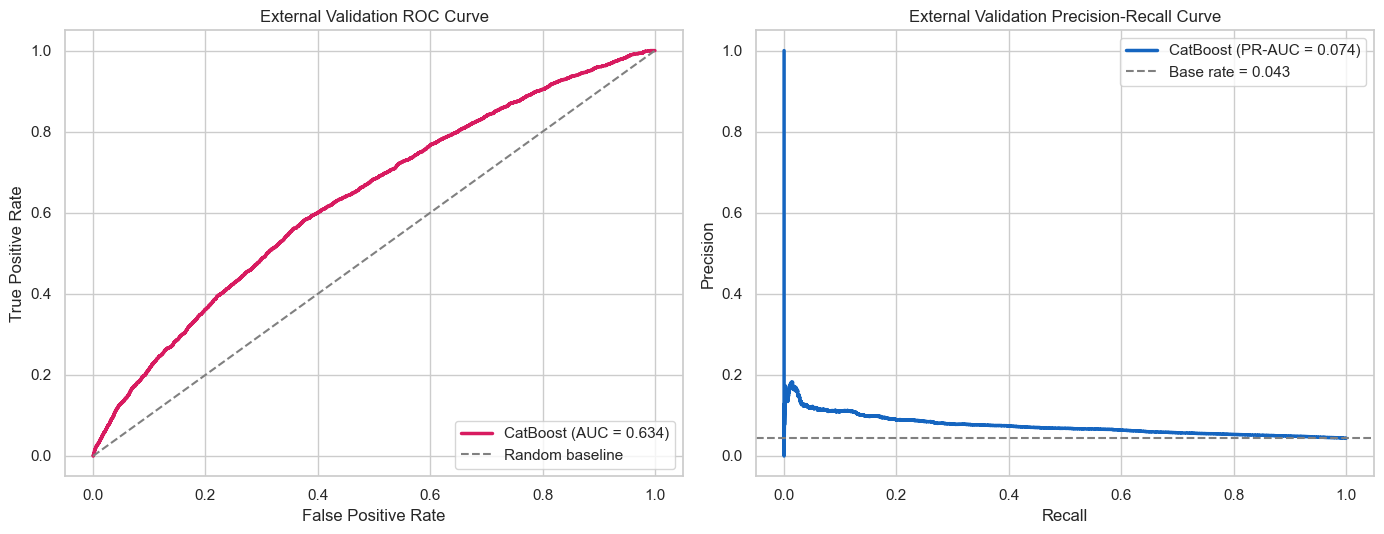

Saved external-validation curves to: F:\ecommerce-recommender-xai\outputs\figures\14_yoochoose_external_validation_curves.png


In [15]:
# Purpose: Create and save ROC and precision-recall curves for the YooChoose external-validation test set.

from sklearn.metrics import precision_recall_curve, roc_curve

false_positive_rate, true_positive_rate, _ = roc_curve(
    y_external_test,
    external_test_probabilities
)

precision_values, recall_values, _ = precision_recall_curve(
    y_external_test,
    external_test_probabilities
)

external_base_purchase_rate = y_external_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].plot(
    false_positive_rate,
    true_positive_rate,
    color="#D81B60",
    linewidth=2.5,
    label=f"CatBoost (AUC = {external_catboost_results['roc_auc']:.3f})"
)
axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random baseline"
)
axes[0].set_title("External Validation ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

axes[1].plot(
    recall_values,
    precision_values,
    color="#1565C0",
    linewidth=2.5,
    label=f"CatBoost (PR-AUC = {external_catboost_results['pr_auc']:.3f})"
)
axes[1].axhline(
    external_base_purchase_rate,
    linestyle="--",
    color="gray",
    label=f"Base rate = {external_base_purchase_rate:.3f}"
)
axes[1].set_title("External Validation Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right")

plt.tight_layout()

external_curve_path = figures_dir / "14_yoochoose_external_validation_curves.png"
plt.savefig(external_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved external-validation curves to: {external_curve_path}")

## External Validation Summary

The original Retailrocket model cannot be directly transferred to YooChoose because the datasets differ in user identity structure and available event types. Retailrocket provides persistent visitor histories and cart events, whereas YooChoose provides anonymous session-level clicks and purchases.

Therefore, an equivalent click-to-purchase task was constructed in YooChoose: predicting whether an item would be purchased later in the same session after its first click. The external CatBoost model achieved a ROC-AUC of 0.6337 and a PR-AUC of 0.0741, exceeding the test-set purchase base rate of 0.0435.

Using the threshold selected on the chronological validation set (0.06), the model identified 28.11% of real purchases with a precision of 8.11%. This indicates useful ranking ability in a different e-commerce setting, while also showing that predictions should be used for low-cost personalization rather than costly incentives.

### Saved external-validation outputs

- `yoochoose_clicks_session_sample_1_64.csv`: reproducible sampled click dataset
- `yoochoose_buys_session_sample_1_64.csv`: purchases matched to sampled sessions
- `yoochoose_click_to_purchase_modeling_dataset.csv`: external session-item modeling dataset
- `11_yoochoose_external_validation_model_comparison.csv`: external model comparison
- `14_yoochoose_external_validation_curves.png`: ROC and precision-recall curves
- `external_yoochoose_click_to_purchase_catboost.cbm`: trained external-validation model